In [415]:
from pathlib import Path
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.models as models
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
from torchvision import transforms 
from sklearn.svm import OneClassSVM
import pickle
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [416]:
# Check if we can use the GPU or the CPU by checking if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [417]:
############################## Data loading function from Notebook 01##########################
#Function that returns a list of all training image pahts AND a list of all test image paths
# with their lables (good = 0, defective = 1)
def load_data_paths(category):
    train_folder_path = Path('C:/Users/ylazz/Desktop/defect-detection/data/raw/archive/'+ category +'/train/good')
    test_folder_path = Path('C:/Users/ylazz/Desktop/defect-detection/data/raw/archive/'+ category +'/test')
    
    training_data = list(train_folder_path.glob('*.jpg'))

    testing_data = []
    for folder in test_folder_path.iterdir():
        if folder.is_dir():
            if folder.name == "good":
                label = 0
            else:
                label = 1

            images = list(folder.glob('*.jpg'))

            for img_path in images:
                testing_data.append((img_path, label))
    
    return training_data, testing_data

In [420]:
#Adding noise to the training images
def add_noise(image_tensor, noise_factor=0.05):
    # Add small random noise to the image tensor
    # noise_factor controls how strong the noise is
    # 0.05 means noise is 5% of the pixel value range
    noise = torch.randn_like(image_tensor)*noise_factor
    noisy_images = image_tensor + noise
    #Clamiping the values between 0 and 1 to avoid negative pixels
    noisy_images = torch.clamp(noisy_images,0,1)
    return noisy_images

In [421]:
# Creating the Dataset Class
class DefectDataset(Dataset):
    def __init__(self, image_paths, labels, augment = False):
        self.image_paths = image_paths
        self.labels = labels
        self.augment = augment

        if self.augment:
            self.transform = transforms.Compose([
                transforms.RandomResizedCrop(size=(224,224), scale=(0.90,1.0)), #we moved the image resize here
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(degrees=10),
                transforms.ColorJitter(brightness=0.1, contrast = 0.0, saturation=0.0, hue=0.0),
                transforms.RandomAffine(degrees=0, translate=(0.10,0.10))
            ])
        else:
            self.transform = None #no augmentation for test images

    def __len__(self):
        return len(self.image_paths)
        

    def __getitem__(self, index):          # Ex. index 5
        path = self.image_paths[index]     # Get path at index 5
        #image = preprocess_image(path)    # Preprocess that image in that path
        img = Image.open(path)
        if img.mode != 'RGB':
            img = img.convert('RGB')

        img = img.resize((224,224)) 

        #Apply augmentation IF this is the training data
        if self.augment:
            img = self.transform(img)
        
        img_array = np.array(img)
        normalized_img = img_array / 255.0
        normalized_img = normalized_img.transpose(2, 0, 1)
        normalized_img = normalized_img.astype(np.float32)
        
        label = self.labels[index]         # Get the label at that index
      
        return normalized_img,label                # Return the preprocessed image as well as its label


In [423]:
#Creating the autoencoder
class DefectAutoencoder(nn.Module):
    def __init__(self):
        super(DefectAutoencoder, self).__init__()

        #Pretrained model
        resnet = models.resnet18(weights = 'IMAGENET1K_V1')

        self.encoder = nn.Sequential(
            resnet.conv1, #224 to 112
            resnet.bn1,
            resnet.relu,
            resnet.maxpool, #112 to 56
            resnet.layer1,  #56 to 56 (64 channels)
            resnet.layer2,  # 56 to 28 (128 channels)
            resnet.layer3,  # 28 to 14 (256 channels)
            resnet.layer4   #14 to 7  (512 channels)
        )
        

        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(512, 512, kernel_size = 3, padding = 1), #Stride makes it bigger by 2x
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(512, 256, kernel_size = 3, padding = 1), #Stride makes it bigger by 2x
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(256,128, kernel_size = 3, padding = 1), #output_padding=1 ensures we get exactly the right size
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(128,64, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(64,3, kernel_size = 3, padding = 1),
            nn.Sigmoid() #Images are normalized with values from 0 to 1, so we use Sigmoid
        )


    def forward(self, x):
            #Pass through the encoder
            encoded = self.encoder(x)
            #Pass through the decoder
            decoded = self.decoder(encoded)
            return decoded

In [427]:
#Training function
def train_autoencoder_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, _ in dataloader: #ignore the labels
        images = images.to(device)

        optimizer.zero_grad() #clears the gradient from the last batch
        #noisy_images = add_noise(images, noise_factor = 0.05)
        reconstructed = model(images)

        loss = criterion (reconstructed, images)
        loss.backward()
        optimizer.step()
        running_loss = running_loss + loss.item()*images.size(0)
        #loss.item(converts a python tensor into a number. Average loss for the current batch
        #image.size(0) since the image is size [32, 3, 224, 224], this line returns the first dimension, 32. For the last batch it might be 16 or 17
        #loss.item*image.size(0): multiplies the average loss by the number of images (basically the total loss for a batch of X number of images)
        #running_loss = : accumulates the entire loss across all batches

    #if (epoch + 1) % 5 == 0:
        #print(f"Epoch [{epoch+1}/{num_epoch}], Loss: {epoch_loss: 4f}") 
    
    epoch_loss = running_loss/len(dataloader.dataset) #total loss across all batches divided by the total number of images in the dataloader
    return epoch_loss

In [430]:
all_categories = ["cat_food"]

In [431]:
all_train_paths = []
all_test_data = []

for category in all_categories:
    train_path, test_data = load_data_paths(category)
    all_train_paths.extend(train_path)
    all_test_data.extend(test_data)

print(f"Total training images: {len(all_train_paths)}")
print(f"Total test images: {len(all_test_data)}")

Total training images: 255
Total test images: 178


In [432]:
#data loader for al categories
#train_paths, test_data = load_data_paths('bottle')
all_train_labels = [0] * len(all_train_paths) #creates a list of zeros as long as all train paths since all training images are good
train_dataset = DefectDataset(all_train_paths, all_train_labels, augment=True) #creates a dataset object that pairs each image with its label EX Item 0: ('bottle1.jpg', 0)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0) #Groups images into batches of 32 for training

all_test_paths = [path for path, label in all_test_data] #the test data is comprised by tuples. This takes the path...
all_test_labels = [label for path, label in all_test_data] # this takes the labels. We split them because the class defectDataset expects two arguments:
                                                            # one is the path, the other is the label
test_dataset = DefectDataset(all_test_paths, all_test_labels, augment = False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 16
Test batches: 12


In [433]:
#Creating a fresh autoencoder and train all the data

model = DefectAutoencoder() #creates a new autoencoder test model, initializing layers and making the model eists in memory
model = model.to(device) #moves the model to the CPU, same place where the data lives

#model.encoder.requires_grad_(False) ###################### FREEZE the autoencoder

images, _ = next(iter(train_loader)) #creates an iterator (a machine that hands out batches one at the time
                                        # my train_loader has 7 batches (32 images each)
images = images.to(device) #movetest image to CPU

print(f"Input shape: {images.shape}")

output = model(images)
print(f"Output shape: {output.shape}")

Input shape: torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 3, 224, 224])


In [435]:
loss_fn = nn.MSELoss() # Mean squared error

#For use with pretrained model. Train encoder and decoder with different learning rates
optimizer = torch.optim.Adam([
     {'params':model.encoder.parameters(), 'lr':0.00005},
     {'params':model.decoder.parameters(),'lr':0.001}
 ])



In [436]:
 #Training the model
num_epochs = 40
train_losses = []
for epoch in range(num_epochs):
    loss = train_autoencoder_epoch(model, train_loader, loss_fn, optimizer, device)
    train_losses.append(loss)
    print(f"Epoch: {epoch+1}/{num_epochs}, Loss: {loss:.4f}")

print("Training complete")

Epoch: 1/40, Loss: 0.0225
Epoch: 2/40, Loss: 0.0094
Epoch: 3/40, Loss: 0.0078
Epoch: 4/40, Loss: 0.0070
Epoch: 5/40, Loss: 0.0064
Epoch: 6/40, Loss: 0.0062
Epoch: 7/40, Loss: 0.0055
Epoch: 8/40, Loss: 0.0053
Epoch: 9/40, Loss: 0.0050
Epoch: 10/40, Loss: 0.0048
Epoch: 11/40, Loss: 0.0047
Epoch: 12/40, Loss: 0.0044
Epoch: 13/40, Loss: 0.0042
Epoch: 14/40, Loss: 0.0042
Epoch: 15/40, Loss: 0.0041
Epoch: 16/40, Loss: 0.0038
Epoch: 17/40, Loss: 0.0038
Epoch: 18/40, Loss: 0.0038
Epoch: 19/40, Loss: 0.0035
Epoch: 20/40, Loss: 0.0037
Epoch: 21/40, Loss: 0.0037
Epoch: 22/40, Loss: 0.0036
Epoch: 23/40, Loss: 0.0034
Epoch: 24/40, Loss: 0.0034
Epoch: 25/40, Loss: 0.0032
Epoch: 26/40, Loss: 0.0032
Epoch: 27/40, Loss: 0.0032
Epoch: 28/40, Loss: 0.0031
Epoch: 29/40, Loss: 0.0030
Epoch: 30/40, Loss: 0.0032
Epoch: 31/40, Loss: 0.0030
Epoch: 32/40, Loss: 0.0028
Epoch: 33/40, Loss: 0.0031
Epoch: 34/40, Loss: 0.0030
Epoch: 35/40, Loss: 0.0029
Epoch: 36/40, Loss: 0.0027
Epoch: 37/40, Loss: 0.0028
Epoch: 38/

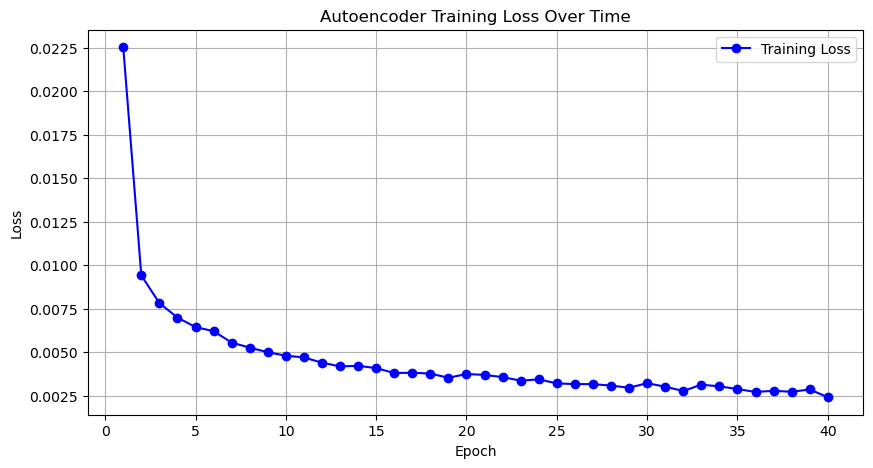

In [437]:
#Plotting the loss of the autoencoder
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), train_losses, marker='o', color='blue', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Autoencoder Training Loss Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [438]:
# Define save path
save_path = Path('C:/Users/ylazz/Desktop/defect-detection/models/saved_models/autoencoder_cat_food_MSE_0.pth')

torch.save(model.state_dict(), str(save_path))
print(f"Model saved to {save_path}")

Model saved to C:\Users\ylazz\Desktop\defect-detection\models\saved_models\autoencoder_cat_food_MSE_0.pth


In [439]:
## Calculate error
## Image shape is  [32, 3, 224, 224]: 32 images in the batch, each image has 3 channels (RGB), each channel is 224x224
def calculate_reconstruction_error(model, images, device):
    model.eval() #go from training mode to test mode
    with torch.no_grad(): #does not track gradients. We don't need it, we are testing
        images = images.to(device)
        reconstructed = model(images) #images go through encoder, then decoder and come out the same shape as listed before
        error = (reconstructed - images)**2 #error between pixels of reconstructed image and original image of a single image (the squared error)
                                            #error has the same shape as the image however [32, 3, 224, 224]. We want a single number per image
                                            # REMEMBER: this is the numeric distance between two arrays of numbers
        error_per_image = error.mean(dim=(1, 2, 3)) # this basically returns a vector of size 32, with 32 errors. One per each image
                                                                      #When I find the error per image, I flatten the error for each image (which is still 3×224×224) 
                                                                      # and then average all those values, so I end up with one scalar error per image (32 in total)
        return error_per_image

#Image 0 → flatten to 150,528 values
#Image 1 → flatten to 150,528 values
#..........
#Image 31 → flatten to 150,528 values
# resulting shape: [32, 150528]. Find the average within each image
# final shape [32] (meaning error_per_image is a 1D tensor with 32 values in it)

# error.mean(dim=(1, 2, 3)) means:
# dim=1 → average over channels
# dim=2 → average over height
# dim=3 → average over width
# do NOT touch dim=0 (the batch)
# So for each image in the batch:
# average all its pixel errors
# get one number per image

In [440]:
def find_anomaly_threshold(model, dataloader, device):
    model.eval()
    all_errors = []

    with torch.no_grad():
        for images, _ in dataloader:
            error = calculate_reconstruction_error(model, images, device)
            all_errors.extend(error.cpu().tolist()) #NOTE Anytime you convert a PyTorch tensor to something else (numpy, list, etc.), use .cpu() first.
    threshold = np.percentile(all_errors, 95)
    return threshold

In [441]:
threshold = find_anomaly_threshold(model, train_loader, device)

In [442]:
threshold

0.0033067821990698573

In [443]:
# THRESHOLD: 95% of good images have error <= 0.00906

In [445]:
#Testing the mode on test images
def evaluate_model(model, dataloader, threshold, device):
    model.eval()
    all_predictions = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            error = calculate_reconstruction_error(model, images, device) #Tensor with 32 numbers
            predictions = (error>threshold).long() #errors>threshold returns [true, true, false, false] depending on the comparison
                                                #.long() turns that unto [1,1,0,0]

            all_predictions.extend(predictions.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    # correct = 0
    # for i in range(len(all_predictions)):
    #     if all_predictions[i] == all_labels[i]:
    #         correct += 1
    # total = len(all_labels)
    accuracy = 100 * accuracy_score(all_labels, all_predictions)
    recall = 100*recall_score(all_labels, all_predictions)
    precision = 100*precision_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions)
    return accuracy, all_predictions, all_labels, recall, precision, f1
        

In [446]:
accuracy, predictons, labels, recall, precision, f1 = evaluate_model(model, test_loader, threshold, device)

In [447]:
print(f"Accuracy: {accuracy}") #Out of ALL images (both good and defective), what percentage did the model get right?
print(f"Recall: {recall}") #Out of every X defective bottles, how many did i catch?
print(f"Precision: {precision}") #Out of every X bottles flagged as defective, how many bottles actually ARE defective
print(f"F1 Score: {f1}")

Accuracy: 33.70786516853933
Recall: 3.278688524590164
Precision: 100.0
F1 Score: 0.06349206349206349


In [448]:
#checking where the model missed the prediction
for i in range(len(predictons)):
    if predictons[i] != labels[i]:
        print(f"Image {i}: Predicted {predictons[i]}, Actually {labels[i]}")

Image 0: Predicted 0, Actually 1
Image 1: Predicted 0, Actually 1
Image 2: Predicted 0, Actually 1
Image 3: Predicted 0, Actually 1
Image 4: Predicted 0, Actually 1
Image 5: Predicted 0, Actually 1
Image 6: Predicted 0, Actually 1
Image 7: Predicted 0, Actually 1
Image 8: Predicted 0, Actually 1
Image 9: Predicted 0, Actually 1
Image 10: Predicted 0, Actually 1
Image 11: Predicted 0, Actually 1
Image 12: Predicted 0, Actually 1
Image 13: Predicted 0, Actually 1
Image 14: Predicted 0, Actually 1
Image 15: Predicted 0, Actually 1
Image 20: Predicted 0, Actually 1
Image 21: Predicted 0, Actually 1
Image 22: Predicted 0, Actually 1
Image 23: Predicted 0, Actually 1
Image 24: Predicted 0, Actually 1
Image 25: Predicted 0, Actually 1
Image 26: Predicted 0, Actually 1
Image 27: Predicted 0, Actually 1
Image 28: Predicted 0, Actually 1
Image 29: Predicted 0, Actually 1
Image 30: Predicted 0, Actually 1
Image 31: Predicted 0, Actually 1
Image 32: Predicted 0, Actually 1
Image 33: Predicted 0, A

In [449]:
# Calculate errors on ALL test images
all_test_errors = []
with torch.no_grad():
    for images, labels in test_loader:
        errors = calculate_reconstruction_error(model, images, device)
        all_test_errors.extend(errors.cpu().tolist())

# Find what threshold would work
good_errors = [all_test_errors[i] for i in range(len(all_test_errors)) if all_test_labels[i] == 0]
defect_errors = [all_test_errors[i] for i in range(len(all_test_errors)) if all_test_labels[i] == 1]

print(f"Good image errors - Mean: {np.mean(good_errors):.6f}, Max: {np.max(good_errors):.6f}")
print(f"Defect image errors - Mean: {np.mean(defect_errors):.6f}, Min: {np.min(defect_errors):.6f}")

# Try threshold between them
new_threshold = (np.max(good_errors) + np.min(defect_errors)) / 2
print(f"Suggested new threshold: {new_threshold:.6f}")

Good image errors - Mean: 0.002180, Max: 0.003124
Defect image errors - Mean: 0.002430, Min: 0.001690
Suggested new threshold: 0.002407


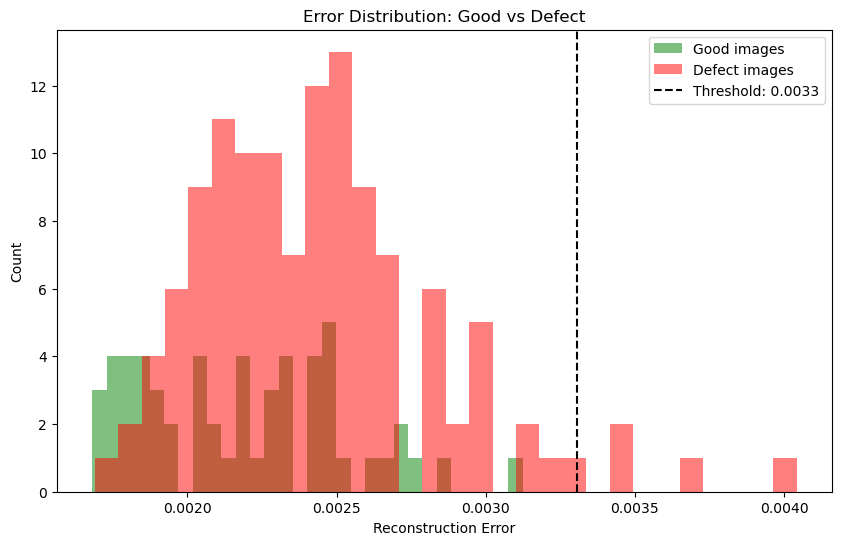

Good images: 56
Defect images: 122


In [450]:
import matplotlib.pyplot as plt

# Plot histogram of errors
plt.figure(figsize=(10, 6))
plt.hist(good_errors, bins=30, alpha=0.5, label='Good images', color='green')
plt.hist(defect_errors, bins=30, alpha=0.5, label='Defect images', color='red')
plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold: {threshold:.4f}')
plt.xlabel('Reconstruction Error')
plt.ylabel('Count')
plt.legend()
plt.title('Error Distribution: Good vs Defect')
plt.show()

print(f"Good images: {len(good_errors)}")
print(f"Defect images: {len(defect_errors)}")

In [451]:
# Check what you actually loaded
print(f"Training images: {len(all_train_paths)}")
print(f"Training labels - unique values: {set(all_train_labels)}")
print(f"Are all training labels 0? {all(label == 0 for label in all_train_labels)}")

Training images: 255
Training labels - unique values: {0}
Are all training labels 0? True


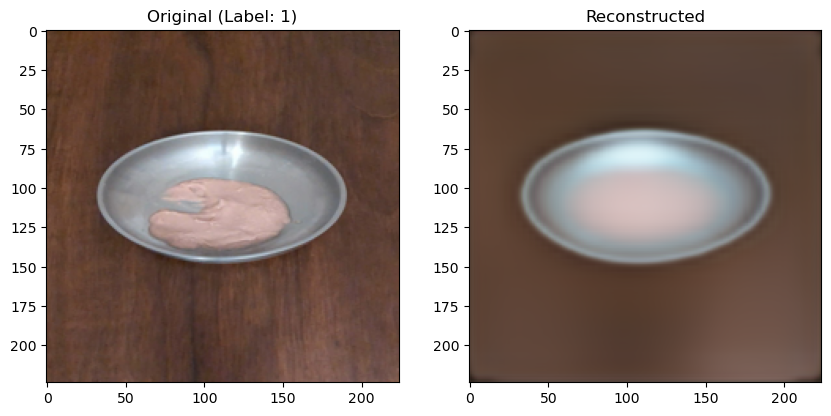

In [452]:
# Get one test image
test_images, test_labels = next(iter(test_loader)) #converts test loader into an iterator. test loader has several batches of 32 images each
                                                    #next gives me batch 0. If i were to call next again, i'd get batch 1 with 
                                                    #test_images2, test_labels2 = next(iter(test_loader))
model.eval()

with torch.no_grad():
    reconstructed = model(test_images.to(device))

# Show original vs reconstructed for first image
import matplotlib.pyplot as plt

original = test_images[0].cpu().numpy().transpose(1, 2, 0)
recon = reconstructed[0].cpu().numpy().transpose(1, 2, 0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original)
axes[0].set_title(f'Original (Label: {test_labels[0]})')
axes[1].imshow(recon)
axes[1].set_title('Reconstructed')
plt.show()

#DECODER DID NOT WORK AS EXPECTED. MOVING ON TO ONE CLASS SVM

### ONE CLASS SVM

In [455]:
# LOADING THE MODEL

model = DefectAutoencoder()
model.load_state_dict(torch.load('C:/Users/ylazz/Desktop/defect-detection/models/saved_models/autoencoder_cat_food_MSE_0.pth', weights_only=False))
model = model.to(device)
model.eval()

print("Model loaded successuflly")

Model loaded successuflly


In [456]:
# Now we run the training images through the encoder to get the features (only the ones in the last epoch)

In [458]:
all_train_features = [] #becomes a python list with a tensor for each batch. SVM needs ONE tensor, not several. So we concat

for images, _  in train_loader: #loop through batches int he train loader. Each batch has 32 images
    images = images.to(device)
    with torch.no_grad():
        features = model.encoder(images) #extract features of the last epoch [32,512,7,7] 
        features = features.flatten(start_dim = 1) #flatten the images [32, 25088] into one long list of 25088 numbers
        all_train_features.append(features) #store this batch

all_train_features = torch.cat(all_train_features, dim = 0)  # Concatenate along batch dimension       
print(f"Total features shape: {all_train_features.shape}")
print(f"Number of training images: {all_train_features.shape[0]}")

Total features shape: torch.Size([255, 25088])
Number of training images: 255


In [459]:
#### After APPEND
#List of 4 tensors
# [
#   [[1, 2, 3],    # Batch 1
#    [4, 5, 6]],
   
#   [[7, 8, 9]],   # Batch 2
  
#   [[10, 11, 12]], # Batch 3
  
#   [[13, 14, 15]]  # Batch 4
# ]

#### AFTER CONCAT
# One tensor
# [[1, 2, 3],
#  [4, 5, 6],
#  [7, 8, 9],
#  [10, 11, 12],
#  [13, 14, 15]]



In [460]:
# we now have a 'table' with 102 rows and 25088 columns
#SVM needs Numpy arrays, not tensors
train_features_numpy = all_train_features.cpu().numpy()
print(f"Type: {type(train_features_numpy)}")
print(f"Shape: {train_features_numpy.shape}")

Type: <class 'numpy.ndarray'>
Shape: (255, 25088)


In [461]:
## TRAIN the SVM

svm = OneClassSVM(kernel = 'rbf', nu = 0.05) #I expect ~5% of my training data might be slight outliers"
svm.fit(train_features_numpy)
print("SVM trained")

SVM trained


In [462]:
## now we need to extract the test features from the test images
all_test_features = []
for images, _ in test_loader:
    images = images.to(device)
    with torch.no_grad():
        features = model.encoder(images) #extract features of the last epoch [32,512,7,7] 
        features = features.flatten(start_dim = 1) #flatten the images [32, 25088] into one long list of 25088 numbers
        all_test_features.append(features) #store this batch

all_test_features = torch.cat(all_test_features, dim = 0)  # Concatenate along batch dimension       
#print(f"Total features shape: {all_test_features.shape}")
#print(f"Number of training images: {all_test_features.shape[0]}")
test_features_numpy = all_test_features.cpu().numpy()
print(f"Type: {type(test_features_numpy)}")
print(f"Shape: {test_features_numpy.shape}")

Type: <class 'numpy.ndarray'>
Shape: (178, 25088)


In [463]:
#predict on test features
predictions = svm.predict(test_features_numpy)

print(f"Predictions shape: {predictions.shape}")
print(f"Unique values: {np.unique(predictions)}")

Predictions shape: (178,)
Unique values: [-1  1]


In [464]:
#Extract the true labels from test_loader.
all_test_labels= []
for _, labels in test_loader:
    all_test_labels.extend(labels.tolist()) #pytorch tensor before converting to a list
all_test_labels = np.array(all_test_labels)

print(f"True labels shape: {all_test_labels.shape}")
print(f"Unique labels: {np.unique(all_test_labels)}")

True labels shape: (178,)
Unique labels: [0 1]


In [465]:
#Convert SVM predictions to match the label format.
predictions_converted = (predictions == -1).astype(int)

print(f"Converted predictions: {np.unique(predictions_converted)}")

# Checks each value: "Is this equal to -1?"
#[False, False, True, True, True, False, True, ...]

# Converts True → 1, False → 0
#[0, 0, 1, 1, 1, 0, 1, ...]

Converted predictions: [0 1]


In [466]:
accuracy = 100 * accuracy_score(all_test_labels, predictions_converted)
recall = 100*recall_score(all_test_labels, predictions_converted)
precision = 100*precision_score(all_test_labels,predictions_converted)
f1 = f1_score(all_test_labels, predictions_converted)

In [467]:
print(f"Accuracy: {accuracy}") #Out of ALL images (both good and defective), what percentage did the model get right?
print(f"Recall: {recall}") #Out of every X defective bottles, how many did i catch?
print(f"Precision: {precision}") #Out of every X bottles flagged as defective, how many bottles actually ARE defective
print(f"F1 Score: {f1}")

Accuracy: 60.1123595505618
Recall: 43.44262295081967
Precision: 96.36363636363636
F1 Score: 0.5988700564971752


In [468]:

save_path = 'C:/Users/ylazz/Desktop/defect-detection/models/saved_models/svm_detector_MSE_0.pkl'

with open(save_path, 'wb') as f:
    pickle.dump(svm, f)

print(f"✓ SVM saved to: {save_path}")

✓ SVM saved to: C:/Users/ylazz/Desktop/defect-detection/models/saved_models/svm_detector_MSE_0.pkl


In [469]:
# Calculate confusion matrix
cm = confusion_matrix(all_test_labels, predictions_converted)

print("Confusion Matrix:")
print(cm)
print("\nBreakdown:")
print(f"True Negatives (correctly identified good): {cm[0,0]}")
print(f"False Positives (good flagged as defect): {cm[0,1]}")
print(f"False Negatives (defect missed): {cm[1,0]}")
print(f"True Positives (correctly identified defect): {cm[1,1]}")

Confusion Matrix:
[[54  2]
 [69 53]]

Breakdown:
True Negatives (correctly identified good): 54
False Positives (good flagged as defect): 2
False Negatives (defect missed): 69
True Positives (correctly identified defect): 53


In [470]:
# Get decision scores (how far from boundary)
decision_scores = svm.decision_function(test_features_numpy)

print(f"Decision scores shape: {decision_scores.shape}")
print(f"Score range: {decision_scores.min():.4f} to {decision_scores.max():.4f}")

Decision scores shape: (178,)
Score range: -0.5438 to 0.3328


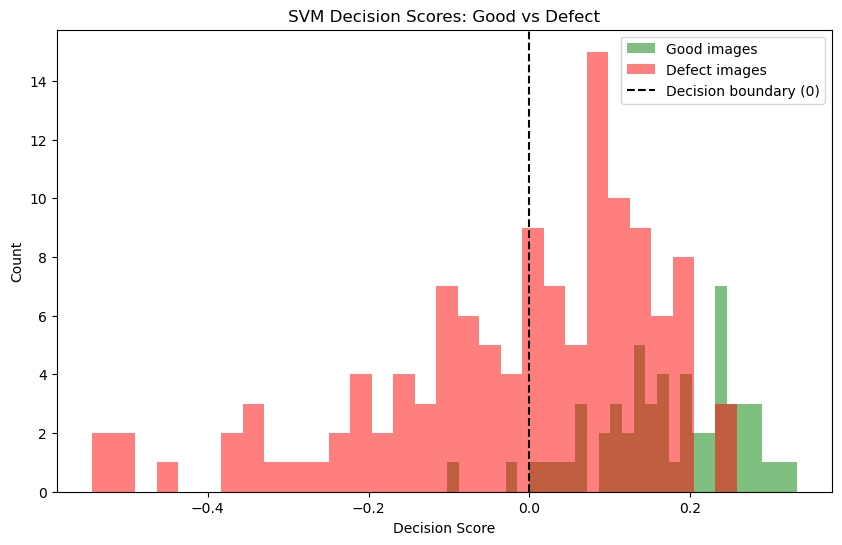

Good bowls - scores range: -0.1021 to 0.3328
Defect bowls - scores range: -0.5438 to 0.2584


In [471]:
import matplotlib.pyplot as plt

# Separate scores by true label
good_scores = decision_scores[all_test_labels == 0]
defect_scores = decision_scores[all_test_labels == 1]

# Plot
plt.figure(figsize=(10, 6))
plt.hist(good_scores, bins=30, alpha=0.5, label='Good images', color='green')
plt.hist(defect_scores, bins=30, alpha=0.5, label='Defect images', color='red')
plt.axvline(0, color='black', linestyle='--', label='Decision boundary (0)')
plt.xlabel('Decision Score')
plt.ylabel('Count')
plt.legend()
plt.title('SVM Decision Scores: Good vs Defect')
plt.show()

print(f"Good bowls - scores range: {good_scores.min():.4f} to {good_scores.max():.4f}")
print(f"Defect bowls - scores range: {defect_scores.min():.4f} to {defect_scores.max():.4f}")

In [472]:
# Find misclassified images
false_negatives = []  # Defects that were missed (predicted 0, actually 1)
false_positives = []  # Good bowls flagged as defect (predicted 1, actually 0)

for i in range(len(all_test_labels)):
    true_label = all_test_labels[i]
    predicted_label = predictions_converted[i]
    
    if true_label == 1 and predicted_label == 0:
        false_negatives.append(i)
    elif true_label == 0 and predicted_label == 1:
        false_positives.append(i)

print(f"False Negatives (missed defects): {len(false_negatives)}")
print(f"False Positives (false alarms): {len(false_positives)}")
print(f"\nFirst 10 false negative indices: {false_negatives[:10]}")
print(f"First 10 false positive indices: {false_positives[:10]}")

False Negatives (missed defects): 69
False Positives (false alarms): 2

First 10 false negative indices: [8, 9, 10, 11, 12, 13, 14, 15, 20, 21]
First 10 false positive indices: [122, 177]


In [473]:
# Check what labels are at those indices
print("False positive indices and their TRUE labels:")
for idx in false_positives[:10]:
    print(f"  Index {idx}: true label = {all_test_labels[idx]}")

print("\nFalse negative indices and their TRUE labels:")
for idx in false_negatives[:10]:
    print(f"  Index {idx}: true label = {all_test_labels[idx]}")

False positive indices and their TRUE labels:
  Index 122: true label = 0
  Index 177: true label = 0

False negative indices and their TRUE labels:
  Index 8: true label = 1
  Index 9: true label = 1
  Index 10: true label = 1
  Index 11: true label = 1
  Index 12: true label = 1
  Index 13: true label = 1
  Index 14: true label = 1
  Index 15: true label = 1
  Index 20: true label = 1
  Index 21: true label = 1


In [474]:
# Get the actual image paths from test dataset
false_negative_paths = [all_test_paths[i] for i in false_negatives[:5]]
false_positive_paths = [all_test_paths[i] for i in false_positives[:5]]

print("First 5 FALSE NEGATIVES (defects that were missed):")
for i, path in enumerate(false_negative_paths):
    print(f"{i+1}. {path}")

print("\nFirst 5 FALSE POSITIVES (good bowls flagged as defect):")
for i, path in enumerate(false_positive_paths):
    print(f"{i+1}. {path}")

First 5 FALSE NEGATIVES (defects that were missed):
1. C:\Users\ylazz\Desktop\defect-detection\data\raw\archive\cat_food\test\eaten\camo_20260306_081547.jpg
2. C:\Users\ylazz\Desktop\defect-detection\data\raw\archive\cat_food\test\eaten\camo_20260306_081634.jpg
3. C:\Users\ylazz\Desktop\defect-detection\data\raw\archive\cat_food\test\eaten\camo_20260306_081658.jpg
4. C:\Users\ylazz\Desktop\defect-detection\data\raw\archive\cat_food\test\eaten\camo_20260306_081721.jpg
5. C:\Users\ylazz\Desktop\defect-detection\data\raw\archive\cat_food\test\eaten\camo_20260306_081750.jpg

First 5 FALSE POSITIVES (good bowls flagged as defect):
1. C:\Users\ylazz\Desktop\defect-detection\data\raw\archive\cat_food\test\good\camo_20260305_194752.jpg
2. C:\Users\ylazz\Desktop\defect-detection\data\raw\archive\cat_food\test\good\camo_20260316_153147.jpg


In [475]:
# Analyze decision score distribution for defects only
defect_scores = decision_scores[all_test_labels == 1]

# Calculate percentiles
percentiles = [10, 25, 50, 75, 90]
for p in percentiles:
    value = np.percentile(defect_scores, p)
    print(f"{p}th percentile of defect scores: {value:.4f}")

print(f"\nMean defect score: {defect_scores.mean():.4f}")
print(f"Good bowls range: {decision_scores[all_test_labels == 0].min():.4f} to {decision_scores[all_test_labels == 0].max():.4f}")

10th percentile of defect scores: -0.2548
25th percentile of defect scores: -0.1109
50th percentile of defect scores: 0.0252
75th percentile of defect scores: 0.1096
90th percentile of defect scores: 0.1609

Mean defect score: -0.0162
Good bowls range: -0.1021 to 0.3328


In [559]:
for touched in [0.15, 0.12, 0.10, 0.08]:
    for refill in [0.05, 0.02, 0.0, -0.02, -0.05, -0.08]:
        states_good = []
        states_defect = []
        for i, score in enumerate(decision_scores):
            if score >= touched:
                state = "Full"
            elif score >= refill:
                state = "Touched"
            else:
                state = "Refill"
            if all_test_labels[i] == 0:
                states_good.append(state)
            else:
                states_defect.append(state)
        
        good_correct = states_good.count("Full")
        defect_caught = states_defect.count("Touched") + states_defect.count("Refill")
        
        print(f"touched={touched}, refill={refill} | "
              f"Good correct: {good_correct}/52 | "
              f"Defect caught: {defect_caught}/122")

touched=0.15, refill=0.05 | Good correct: 35/52 | Defect caught: 105/122
touched=0.15, refill=0.02 | Good correct: 35/52 | Defect caught: 105/122
touched=0.15, refill=0.0 | Good correct: 35/52 | Defect caught: 105/122
touched=0.15, refill=-0.02 | Good correct: 35/52 | Defect caught: 105/122
touched=0.15, refill=-0.05 | Good correct: 35/52 | Defect caught: 105/122
touched=0.15, refill=-0.08 | Good correct: 35/52 | Defect caught: 105/122
touched=0.12, refill=0.05 | Good correct: 42/52 | Defect caught: 94/122
touched=0.12, refill=0.02 | Good correct: 42/52 | Defect caught: 94/122
touched=0.12, refill=0.0 | Good correct: 42/52 | Defect caught: 94/122
touched=0.12, refill=-0.02 | Good correct: 42/52 | Defect caught: 94/122
touched=0.12, refill=-0.05 | Good correct: 42/52 | Defect caught: 94/122
touched=0.12, refill=-0.08 | Good correct: 42/52 | Defect caught: 94/122
touched=0.1, refill=0.05 | Good correct: 45/52 | Defect caught: 87/122
touched=0.1, refill=0.02 | Good correct: 45/52 | Defect

In [555]:
# Define thresholds
threshold_touched = 0.12  # above this full
threshold_refill = -0.05   # below this refil needed

# Test the thresholds
def classify_bowl_state(score):
    if score >= threshold_touched:
        return "Full"
    elif score >= threshold_refill:
        return "Touched (monitor)"
    else:
        return "Refill needed"

# Apply to all test images
states = [classify_bowl_state(score) for score in decision_scores]

# Count each state
from collections import Counter
state_counts = Counter(states)

print("Bowl States Distribution:")
for state, count in state_counts.items():
    print(f"  {state}: {count}")

# Show how this maps to actual labels
print("\n--- Breakdown by True Label ---")
for label in [0, 1]:
    label_name = "Good bowls" if label == 0 else "Defective bowls"
    indices = [i for i, l in enumerate(all_test_labels) if l == label]
    label_states = [states[i] for i in indices]
    label_counts = Counter(label_states)
    
    print(f"\n{label_name} ({len(indices)} total):")
    for state, count in label_counts.items():
        print(f"  {state}: {count}")

Bowl States Distribution:
  Refill needed: 44
  Touched (monitor): 64
  Full: 70

--- Breakdown by True Label ---

Good bowls (56 total):
  Refill needed: 1
  Full: 42
  Touched (monitor): 13

Defective bowls (122 total):
  Refill needed: 43
  Touched (monitor): 51
  Full: 28


In [478]:
# Test 1: Load Autoencoder (class already defined in notebook)
model = DefectAutoencoder()  # Uses the class you defined earlier
model.load_state_dict(torch.load('C:/Users/ylazz/Desktop/defect-detection/models/saved_models/autoencoder_cat_food_MSE_0.pth', weights_only=False))
model = model.to(device)
model.eval()
print("✓ Autoencoder loaded successfully")

# Test 2: Load SVM
import pickle

with open('C:/Users/ylazz/Desktop/defect-detection/models/saved_models/svm_detector_MSE_0.pkl', 'rb') as f:
    svm = pickle.load(f)
print("✓ SVM loaded successfully")

# Test 3: Run inference on a test image
from PIL import Image
import numpy as np

# Pick one of your test images
test_image_path = all_test_paths[0]  # Use first test image
test_image = Image.open(test_image_path)
test_image = test_image.resize((224, 224))

# Preprocess
img_array = np.array(test_image) / 255.0
img_array = img_array.transpose(2, 0, 1).astype(np.float32)
img_tensor = torch.from_numpy(img_array).unsqueeze(0).to(device)

# Extract features
with torch.no_grad():
    features = model.encoder(img_tensor)
    features = features.flatten(start_dim=1).cpu().numpy()

# Predict
score = svm.decision_function(features)[0]
print(f"\nDecision score: {score:.4f}")

# Apply thresholds
if score >= -0.02:
    status = "Full"
elif score >= -0.31:
    status = "Touched"
else:
    status = "Refill needed"
    
print(f"Bowl status: {status}")
print(f"Image: {test_image_path}")

✓ Autoencoder loaded successfully
✓ SVM loaded successfully

Decision score: -0.2565
Bowl status: Touched
Image: C:\Users\ylazz\Desktop\defect-detection\data\raw\archive\cat_food\test\eaten\camo_20260305_193846.jpg
